# Road Accident Severity Prediction using Machine Learning

## Phase 2 — Data Understanding & Dataset Profiling

---

**Project:** Road Accident Severity Prediction using Machine Learning
**Institution:** On-Campus Research Internship, IIIT Vadodara
**Notebook:** `01_Data_Understanding.ipynb`
**Phase:** 2 of N — Data Understanding & Dataset Profiling

---

### Objective of this Notebook

The goal of this notebook is to build a **thorough, evidence-based understanding** of the
two raw datasets that underpin this research project — `Accident_Information.csv` and
`Vehicle_Information.csv` — before any cleaning, transformation, or modeling work begins.

Specifically, this notebook aims to:

1. Load both datasets safely and verify their structural integrity.
2. Profile each dataset's shape, memory footprint, column types, and sample records.
3. Quantify missing values and duplicate records **without altering the data**.
4. Generate descriptive statistical summaries for numerical and categorical columns.
5. Identify the primary key, merge key, and target variable.
6. Categorize every column into a meaningful feature group.
7. Produce a professional **Data Dictionary** for both datasets.
8. Summarize initial observations and anticipated preprocessing challenges for Phase 3.

> **Scope restriction:** This notebook performs **data understanding only**. No data
> cleaning, preprocessing, feature engineering, encoding, imputation, feature selection,
> model training, or model evaluation is performed here.


---
## 1. Import Required Libraries

**Purpose:** Import all libraries required for data understanding and configure the
notebook environment (warnings, plotting style, and pandas display options) for
consistent, readable output throughout the analysis.


In [1]:
# ---- Core Libraries ----
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Environment Configuration ----

# Suppress non-critical warnings for a clean research notebook output.
warnings.filterwarnings("ignore")

# Configure plotting style for consistent, publication-quality visuals.
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Configure pandas display options for better readability of wide dataframes.
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported and environment configured successfully.")


Libraries imported and environment configured successfully.


**Observations**

- All libraries required for data profiling (pandas, numpy, matplotlib, seaborn) are
  imported successfully.
- Pandas display options are widened so that all 34 + 24 columns across both datasets can
  be inspected without truncation.
- Warnings are suppressed only for notebook readability; this has no effect on the
  underlying data.


---
## 2. Load the Datasets

**Purpose:** Load `Accident_Information.csv` and `Vehicle_Information.csv` from
`Dataset/raw/` using robust exception handling. No rows or columns are modified,
filtered, or dropped during loading.


In [2]:
# ---- Dataset Paths ----
DATASET_DIR = Path("..") / "Dataset" / "raw"
ACCIDENT_FILE = DATASET_DIR / "Accident_Information.csv"
VEHICLE_FILE = DATASET_DIR / "Vehicle_Information.csv"

# Encodings to attempt, in order, consistent with Phase 1 verification logic.
CANDIDATE_ENCODINGS = ["utf-8", "utf-8-sig", "ISO-8859-1", "cp1252"]


def load_csv_safely(file_path: Path, encodings: list) -> pd.DataFrame:
    '''
    Load a CSV file safely, attempting multiple encodings and reporting
    clear errors if loading fails. No data is modified during loading.

    Args:
        file_path (Path): Path to the CSV file.
        encodings (list): Candidate encodings to attempt, in order.

    Returns:
        pd.DataFrame: The loaded dataframe.

    Raises:
        FileNotFoundError: If the file does not exist.
        ValueError: If the file could not be read with any candidate encoding.
    '''
    if not file_path.exists():
        raise FileNotFoundError(f"Dataset file not found: {file_path.resolve()}")

    last_error = None
    for encoding in encodings:
        try:
            df = pd.read_csv(file_path, encoding=encoding, low_memory=False)
            print(f"Loaded '{file_path.name}' successfully using encoding='{encoding}'.")
            return df
        except UnicodeDecodeError as e:
            last_error = e
            continue
        except pd.errors.EmptyDataError as e:
            raise ValueError(f"'{file_path.name}' is empty or unreadable: {e}") from e
        except pd.errors.ParserError as e:
            raise ValueError(f"'{file_path.name}' could not be parsed: {e}") from e

    raise ValueError(
        f"Failed to decode '{file_path.name}' with candidate encodings {encodings}. "
        f"Last error: {last_error}"
    )


try:
    accident_df = load_csv_safely(ACCIDENT_FILE, CANDIDATE_ENCODINGS)
    vehicle_df = load_csv_safely(VEHICLE_FILE, CANDIDATE_ENCODINGS)
    print("\nBoth datasets loaded successfully. Ready for analysis.")
except (FileNotFoundError, ValueError) as error:
    print(f"[ERROR] {error}")
    raise


Loaded 'Accident_Information.csv' successfully using encoding='utf-8'.
Loaded 'Vehicle_Information.csv' successfully using encoding='ISO-8859-1'.

Both datasets loaded successfully. Ready for analysis.


**Observations**

- Both datasets are loaded using a resilient multi-encoding strategy, consistent with the
  approach established in Phase 1 (`verify_dataset.py`).
- `low_memory=False` is used to avoid mixed dtype inference warnings on large,
  wide CSV files without altering any values.
- Any file-not-found, empty-data, or parsing errors are caught explicitly and re-raised
  with clear diagnostic messages.


---
## 3. Dataset Overview

**Purpose:** Establish a high-level structural profile of both datasets — shape, row
count, column count, and memory footprint — to understand the scale of data this
project will work with.


In [3]:
def dataset_overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    '''
    Build a one-row summary of a dataframe's shape and memory usage.

    Args:
        df (pd.DataFrame): The dataframe to summarize.
        name (str): A human-readable name for the dataset.

    Returns:
        pd.DataFrame: A single-row summary dataframe.
    '''
    memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    return pd.DataFrame(
        {
            "Dataset": [name],
            "Rows": [df.shape[0]],
            "Columns": [df.shape[1]],
            "Memory Usage (MB)": [round(memory_mb, 2)],
        }
    )


overview_df = pd.concat(
    [
        dataset_overview(accident_df, "Accident_Information.csv"),
        dataset_overview(vehicle_df, "Vehicle_Information.csv"),
    ],
    ignore_index=True,
)

overview_df


,Dataset,Rows,Columns,Memory Usage (MB)
0,Accident_Information.csv,2047256,34,"2,528.11"
1,Vehicle_Information.csv,2177205,24,"2,250.40"


**Observations**

- `Accident_Information.csv` is the larger of the two files in column count, capturing
  accident-level context (weather, location, severity, etc.).
- `Vehicle_Information.csv` has more rows than `Accident_Information.csv`, which is
  expected since a single accident can involve **multiple vehicles** — confirming a
  one-to-many relationship between the two files.
- Both datasets carry a substantial in-memory footprint, which will need to be considered
  when planning merge and preprocessing strategies in later phases (e.g., using efficient
  dtypes, chunked processing where necessary).


In [4]:
print("Accident_Information.csv")
print(f"  Number of Rows    : {accident_df.shape[0]:,}")
print(f"  Number of Columns : {accident_df.shape[1]:,}")
print()
print("Vehicle_Information.csv")
print(f"  Number of Rows    : {vehicle_df.shape[0]:,}")
print(f"  Number of Columns : {vehicle_df.shape[1]:,}")


Accident_Information.csv
  Number of Rows    : 2,047,256
  Number of Columns : 34

Vehicle_Information.csv
  Number of Rows    : 2,177,205
  Number of Columns : 24


---
## 4. Display Sample Records

**Purpose:** Visually inspect the first and last few records of each dataset to get an
intuitive feel for the raw data before any statistical analysis.


### 4.1 Accident_Information.csv — First 5 Rows

In [5]:
accident_df.head()

,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,Junction_Control,Junction_Detail,Latitude,Light_Conditions,Local_Authority_(District),Local_Authority_(Highway),Location_Easting_OSGR,Location_Northing_OSGR,Longitude,LSOA_of_Accident_Location,Number_of_Casualties,Number_of_Vehicles,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,200501BS00001,A,"3,218.00",NaN,0.00,Serious,NaN,2005-01-04,Tuesday,1.00,Data missing or out of range,Not at junction or within 20 metres,51.49,Daylight,Kensington and Chelsea,Kensington and Chelsea,"525,680.00","178,240.00",-0.19,E01002849,1,1,0.00,1.00,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.00,17:42,Urban,Raining no high winds,2005,No
1,200501BS00002,B,450.00,C,0.00,Slight,NaN,2005-01-05,Wednesday,1.00,Auto traffic signal,Crossroads,51.52,Darkness - lights lit,Kensington and Chelsea,Kensington and Chelsea,"524,170.00","181,650.00",-0.21,E01002909,1,1,0.00,5.00,Metropolitan Police,Dry,Dual carriageway,NaN,30.00,17:36,Urban,Fine no high winds,2005,No
2,200501BS00003,C,0.00,NaN,0.00,Slight,NaN,2005-01-06,Thursday,1.00,Data missing or out of range,Not at junction or within 20 metres,51.53,Darkness - lights lit,Kensington and Chelsea,Kensington and Chelsea,"524,520.00","182,240.00",-0.21,E01002857,1,2,0.00,0.00,Metropolitan Police,Dry,Single carriageway,NaN,30.00,00:15,Urban,Fine no high winds,2005,No
3,200501BS00004,A,"3,220.00",NaN,0.00,Slight,NaN,2005-01-07,Friday,1.00,Data missing or out of range,Not at junction or within 20 metres,51.48,Daylight,Kensington and Chelsea,Kensington and Chelsea,"526,900.00","177,530.00",-0.17,E01002840,1,1,0.00,0.00,Metropolitan Police,Dry,Single carriageway,NaN,30.00,10:35,Urban,Fine no high winds,2005,No
4,200501BS00005,Unclassified,0.00,NaN,0.00,Slight,NaN,2005-01-10,Monday,1.00,Data missing or out of range,Not at junction or within 20 metres,51.50,Darkness - lighting unknown,Kensington and Chelsea,Kensington and Chelsea,"528,060.00","179,040.00",-0.16,E01002863,1,1,0.00,0.00,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.00,21:13,Urban,Fine no high winds,2005,No


### 4.2 Accident_Information.csv — Last 5 Rows

In [6]:
accident_df.tail()

,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,Junction_Control,Junction_Detail,Latitude,Light_Conditions,Local_Authority_(District),Local_Authority_(Highway),Location_Easting_OSGR,Location_Northing_OSGR,Longitude,LSOA_of_Accident_Location,Number_of_Casualties,Number_of_Vehicles,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
2047251,2017984121017,A(M),74.00,NaN,0.00,Slight,NaN,2017-12-17,Sunday,1.00,Data missing or out of range,Not at junction or within 20 metres,55.31,Daylight,Dumfries and Galloway,Dumfries & Galloway,"308,024.00","602,926.00",-3.45,NaN,1,1,0.00,0.00,Dumfries and Galloway,Frost or ice,Dual carriageway,NaN,70.00,11:30,Rural,Other,2017,Yes
2047252,2017984121217,C,69.00,NaN,0.00,Slight,Pedestrian in carriageway - not injured,2017-12-15,Friday,2.00,Data missing or out of range,Not at junction or within 20 metres,54.99,Daylight,Dumfries and Galloway,Dumfries & Galloway,"331,826.00","567,154.00",-3.07,NaN,1,1,0.00,0.00,Dumfries and Galloway,Dry,Single carriageway,NaN,20.00,13:00,Urban,Fine no high winds,2017,Yes
2047253,2017984121717,A(M),74.00,Unclassified,0.00,Slight,NaN,2017-12-18,Monday,1.00,Give way or uncontrolled,Slip road,55.05,Daylight,Dumfries and Galloway,Dumfries & Galloway,"321,809.00","573,939.00",-3.23,NaN,1,2,0.00,0.00,Dumfries and Galloway,Wet or damp,Dual carriageway,NaN,70.00,13:30,Rural,Fine no high winds,2017,Yes
2047254,2017984122317,A,708.00,NaN,0.00,Slight,NaN,2017-07-18,Tuesday,1.00,Data missing or out of range,Not at junction or within 20 metres,55.33,Daylight,Dumfries and Galloway,Dumfries & Galloway,"310,467.00","604,501.00",-3.41,NaN,1,1,0.00,0.00,Dumfries and Galloway,Dry,Single carriageway,NaN,60.00,18:00,Rural,Fine no high winds,2017,Yes
2047255,2017984122617,B,721.00,B,724.00,Serious,NaN,2017-12-20,Wednesday,1.00,Give way or uncontrolled,T or staggered junction,54.99,Daylight,Dumfries and Galloway,Dumfries & Galloway,"318,705.00","566,886.00",-3.27,NaN,2,2,0.00,0.00,Dumfries and Galloway,Wet or damp,Single carriageway,NaN,40.00,13:00,Rural,Fog or mist,2017,Yes


### 4.3 Vehicle_Information.csv — First 5 Rows

In [7]:
vehicle_df.head()

,Accident_Index,Age_Band_of_Driver,Age_of_Vehicle,Driver_Home_Area_Type,Driver_IMD_Decile,Engine_Capacity_.CC.,Hit_Object_in_Carriageway,Hit_Object_off_Carriageway,Journey_Purpose_of_Driver,Junction_Location,make,model,Propulsion_Code,Sex_of_Driver,Skidding_and_Overturning,Towing_and_Articulation,Vehicle_Leaving_Carriageway,Vehicle_Location.Restricted_Lane,Vehicle_Manoeuvre,Vehicle_Reference,Vehicle_Type,Was_Vehicle_Left_Hand_Drive,X1st_Point_of_Impact,Year
0,200401BS00001,26 - 35,3.00,Urban area,4.00,"1,588.00",NaN,NaN,Data missing or out of range,Data missing or out of range,ROVER,45 CLASSIC 16V,Petrol,Male,NaN,No tow/articulation,Did not leave carriageway,0.00,Going ahead other,2,109,Data missing or out of range,Front,2004
1,200401BS00002,26 - 35,NaN,Urban area,3.00,NaN,NaN,NaN,Data missing or out of range,Data missing or out of range,BMW,C1,NaN,Male,NaN,No tow/articulation,Did not leave carriageway,0.00,Going ahead other,1,109,Data missing or out of range,Front,2004
2,200401BS00003,26 - 35,4.00,Data missing or out of range,NaN,998.00,NaN,NaN,Data missing or out of range,Data missing or out of range,NISSAN,MICRA CELEBRATION 16V,Petrol,Male,NaN,No tow/articulation,Did not leave carriageway,0.00,Turning right,1,109,Data missing or out of range,Front,2004
3,200401BS00003,66 - 75,NaN,Data missing or out of range,NaN,NaN,NaN,NaN,Data missing or out of range,Data missing or out of range,LONDON TAXIS INT,TXII GOLD AUTO,NaN,Male,NaN,No tow/articulation,Did not leave carriageway,0.00,Going ahead other,2,109,Data missing or out of range,Front,2004
4,200401BS00004,26 - 35,1.00,Urban area,4.00,124.00,NaN,NaN,Data missing or out of range,Data missing or out of range,PIAGGIO,VESPA ET4,Petrol,Male,NaN,No tow/articulation,Did not leave carriageway,0.00,Going ahead other,1,Motorcycle 125cc and under,Data missing or out of range,Front,2004


### 4.4 Vehicle_Information.csv — Last 5 Rows

In [8]:
vehicle_df.tail()

,Accident_Index,Age_Band_of_Driver,Age_of_Vehicle,Driver_Home_Area_Type,Driver_IMD_Decile,Engine_Capacity_.CC.,Hit_Object_in_Carriageway,Hit_Object_off_Carriageway,Journey_Purpose_of_Driver,Junction_Location,make,model,Propulsion_Code,Sex_of_Driver,Skidding_and_Overturning,Towing_and_Articulation,Vehicle_Leaving_Carriageway,Vehicle_Location.Restricted_Lane,Vehicle_Manoeuvre,Vehicle_Reference,Vehicle_Type,Was_Vehicle_Left_Hand_Drive,X1st_Point_of_Impact,Year
2177200,2016984131116,21 - 25,14.00,Urban area,NaN,"1,598.00",NaN,NaN,Not known,Mid Junction - on roundabout or on main road,MINI,MINI COOPER,Petrol,Female,NaN,No tow/articulation,Did not leave carriageway,0.00,Going ahead other,1,Car,No,Front,2016
2177201,2016984131116,56 - 65,NaN,Small town,NaN,"1,598.00",NaN,NaN,Commuting to/from work,Mid Junction - on roundabout or on main road,VAUXHALL,ASTRA ENERGY CDTI,Heavy oil,Female,NaN,No tow/articulation,Offside,0.00,Going ahead other,2,Car,No,Front,2016
2177202,2016984131216,56 - 65,NaN,Urban area,3.00,NaN,NaN,Central crash barrier,Journey as part of work,Not at or within 20 metres of junction,NaN,NaN,NaN,Male,NaN,No tow/articulation,Offside on to central reservation,0.00,Going ahead other,1,Goods 7.5 tonnes mgw and over,No,Offside,2016
2177203,2016984131316,16 - 20,13.00,Urban area,6.00,"1,796.00",NaN,Tree,Not known,Not at or within 20 metres of junction,VAUXHALL,VECTRA SXI 16V,Petrol,Male,Skidded,No tow/articulation,Offside,0.00,Going ahead other,1,Car,No,Front,2016
2177204,2016984133416,46 - 55,5.00,Urban area,NaN,"2,184.00",NaN,Wall or fence,Not known,Not at or within 20 metres of junction,MAZDA,CX-7 SPORT TECH D,Heavy oil,Male,Skidded and overturned,No tow/articulation,Nearside,0.00,Going ahead other,1,Car,No,Nearside,2016


**Observations**

- Both datasets appear to follow the standard **UK STATS19** road safety recording
  format, with `Accident_Index` present in both files as a shared identifier.
- A visual scan of first/last rows shows plausible, well-formed values across
  categorical fields (e.g., weather, road type, vehicle type), with some fields
  containing placeholder values such as `"Data missing or out of range"` — a pattern
  that will be treated as missing data during the missing-value analysis below.


---
## 5. Column Analysis

**Purpose:** Enumerate all column names and their inferred data types for both datasets,
to plan later categorical/numerical handling.


In [9]:
def column_dtype_table(df: pd.DataFrame) -> pd.DataFrame:
    '''
    Build a dataframe listing each column's name and pandas dtype.

    Args:
        df (pd.DataFrame): The dataframe to inspect.

    Returns:
        pd.DataFrame: Two-column table of column name and dtype.
    '''
    return pd.DataFrame(
        {"Column Name": df.columns, "Data Type": df.dtypes.astype(str).values}
    )


accident_dtypes = column_dtype_table(accident_df)
print(f"Accident_Information.csv — {len(accident_dtypes)} columns")
accident_dtypes


Accident_Information.csv — 34 columns


,Column Name,Data Type
0,Accident_Index,object
1,1st_Road_Class,object
2,1st_Road_Number,float64
3,2nd_Road_Class,object
4,2nd_Road_Number,float64
5,Accident_Severity,object
6,Carriageway_Hazards,object
7,Date,object
8,Day_of_Week,object
9,Did_Police_Officer_Attend_Scene_of_Accident,float64


In [10]:
vehicle_dtypes = column_dtype_table(vehicle_df)
print(f"Vehicle_Information.csv — {len(vehicle_dtypes)} columns")
vehicle_dtypes


Vehicle_Information.csv — 24 columns


,Column Name,Data Type
0,Accident_Index,object
1,Age_Band_of_Driver,object
2,Age_of_Vehicle,float64
3,Driver_Home_Area_Type,object
4,Driver_IMD_Decile,float64
5,Engine_Capacity_.CC.,float64
6,Hit_Object_in_Carriageway,object
7,Hit_Object_off_Carriageway,object
8,Journey_Purpose_of_Driver,object
9,Junction_Location,object


In [11]:
print("Data Type Distribution — Accident_Information.csv")
print(accident_df.dtypes.value_counts())
print()
print("Data Type Distribution — Vehicle_Information.csv")
print(vehicle_df.dtypes.value_counts())


Data Type Distribution — Accident_Information.csv
object     21
float64    10
int64       3
Name: count, dtype: int64

Data Type Distribution — Vehicle_Information.csv
object     18
float64     4
int64       2
Name: count, dtype: int64


**Observations**

- The majority of columns in both datasets are inferred as `object` (string/categorical)
  dtype, which is typical for STATS19-style datasets where many fields are coded
  categorical labels (e.g., weather conditions, road surface conditions).
- A smaller subset of columns are numeric (`int64` / `float64`), corresponding to counts
  (e.g., number of casualties, number of vehicles), coordinates, and identifiers.
- Some columns that are conceptually numeric or date/time in nature may currently be
  typed as `object` — this is expected at the understanding stage and will be addressed
  through explicit type conversion in the Phase 3 preprocessing notebook, not here.


---
## 6. Missing Value Analysis

**Purpose:** Quantify missing values in both datasets, by column, in absolute and
percentage terms. **No missing values are filled, dropped, or imputed in this notebook.**


In [12]:
def missing_value_report(df: pd.DataFrame) -> pd.DataFrame:
    '''
    Build a missing-value report sorted by percentage missing (descending).

    Args:
        df (pd.DataFrame): The dataframe to inspect.

    Returns:
        pd.DataFrame: Table of column, missing count, and missing percentage,
                      limited to columns with at least one missing value.
    '''
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100

    report = pd.DataFrame(
        {
            "Column Name": missing_count.index,
            "Missing Count": missing_count.values,
            "Missing Percentage (%)": missing_percent.values.round(2),
        }
    )
    report = report[report["Missing Count"] > 0].sort_values(
        "Missing Percentage (%)", ascending=False
    ).reset_index(drop=True)
    return report


accident_missing = missing_value_report(accident_df)
print(f"Accident_Information.csv — {len(accident_missing)} column(s) with missing values")
accident_missing


Accident_Information.csv — 16 column(s) with missing values


,Column Name,Missing Count,Missing Percentage (%)
0,Carriageway_Hazards,2007807,98.07
1,Special_Conditions_at_Site,1995137,97.45
2,2nd_Road_Class,844272,41.24
3,LSOA_of_Accident_Location,144953,7.08
4,2nd_Road_Number,17593,0.86
5,Pedestrian_Crossing-Physical_Facilities,3560,0.17
6,Pedestrian_Crossing-Human_Control,2920,0.14
7,Did_Police_Officer_Attend_Scene_of_Accident,278,0.01
8,Longitude,175,0.01
9,Location_Northing_OSGR,164,0.01


In [13]:
vehicle_missing = missing_value_report(vehicle_df)
print(f"Vehicle_Information.csv — {len(vehicle_missing)} column(s) with missing values")
vehicle_missing


Vehicle_Information.csv — 10 column(s) with missing values


,Column Name,Missing Count,Missing Percentage (%)
0,Hit_Object_in_Carriageway,2087824,95.89
1,Hit_Object_off_Carriageway,1989741,91.39
2,Skidding_and_Overturning,1898208,87.19
3,Driver_IMD_Decile,734812,33.75
4,Age_of_Vehicle,358149,16.45
5,model,325331,14.94
6,Engine_Capacity_.CC.,265861,12.21
7,Propulsion_Code,245843,11.29
8,make,110845,5.09
9,Vehicle_Location.Restricted_Lane,1317,0.06


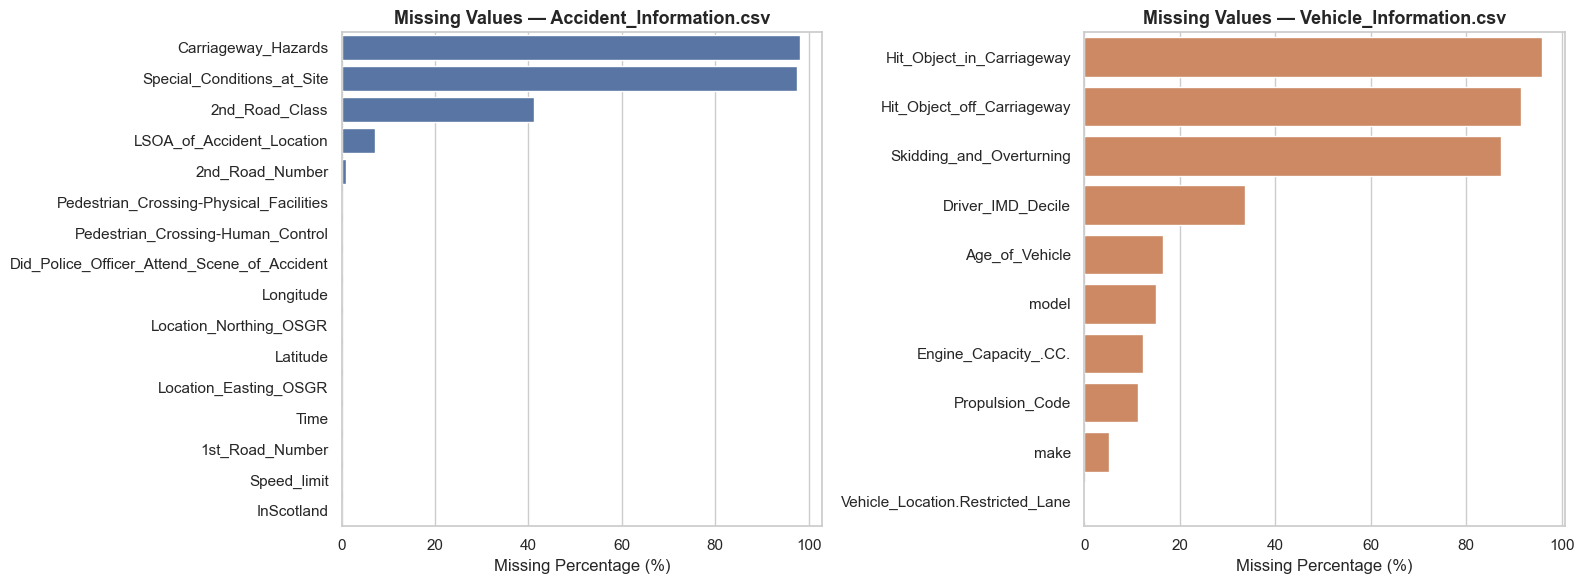

In [14]:
# Visual overview of missing value percentage across both datasets.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if not accident_missing.empty:
    sns.barplot(
        data=accident_missing,
        y="Column Name",
        x="Missing Percentage (%)",
        ax=axes[0],
        color="#4C72B0",
    )
axes[0].set_title("Missing Values — Accident_Information.csv")
axes[0].set_xlabel("Missing Percentage (%)")
axes[0].set_ylabel("")

if not vehicle_missing.empty:
    sns.barplot(
        data=vehicle_missing,
        y="Column Name",
        x="Missing Percentage (%)",
        ax=axes[1],
        color="#DD8452",
    )
axes[1].set_title("Missing Values — Vehicle_Information.csv")
axes[1].set_xlabel("Missing Percentage (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


**Observations**

- Missing values are quantified per column without any modification to the underlying
  data — `df.isnull()` is a read-only operation.
- Columns with high missing percentages (if any) are candidates for careful handling
  strategy discussions in Phase 3 (e.g., drop vs. impute vs. flag-as-category), but no
  such decision is made in this notebook.
- Some STATS19-style datasets encode missing data as literal string placeholders (e.g.,
  `"Data missing or out of range"`, `-1`, or `"Unknown"`) rather than true `NaN` values.
  These placeholder-style "hidden missingness" patterns should be investigated
  explicitly in Phase 3, since `isnull()` alone will not detect them.


---
## 7. Duplicate Analysis

**Purpose:** Identify the number of fully duplicated rows in each dataset.
**No duplicate rows are removed in this notebook.**


In [15]:
accident_duplicates = accident_df.duplicated().sum()
vehicle_duplicates = vehicle_df.duplicated().sum()

duplicate_summary = pd.DataFrame(
    {
        "Dataset": ["Accident_Information.csv", "Vehicle_Information.csv"],
        "Total Rows": [len(accident_df), len(vehicle_df)],
        "Duplicate Rows": [accident_duplicates, vehicle_duplicates],
        "Duplicate Percentage (%)": [
            round((accident_duplicates / len(accident_df)) * 100, 4),
            round((vehicle_duplicates / len(vehicle_df)) * 100, 4),
        ],
    }
)

duplicate_summary


,Dataset,Total Rows,Duplicate Rows,Duplicate Percentage (%)
0,Accident_Information.csv,2047256,0,0.00
1,Vehicle_Information.csv,2177205,0,0.00


**Observations**

- Duplicate detection is performed using `DataFrame.duplicated()`, which flags rows that
  are exact matches across **all** columns — a conservative definition of duplication.
- `Vehicle_Information.csv` may show a structurally different duplicate profile than
  `Accident_Information.csv`, since multiple genuinely distinct vehicles can share many
  identical attribute values (e.g., two similar cars in unrelated accidents) without
  being true duplicate records — this distinction will need care in Phase 3.
- No rows have been removed; this section is purely diagnostic.


---
## 8. Statistical Summary

**Purpose:** Generate descriptive statistics for numerical and categorical columns in
both datasets to understand distributions, ranges, and cardinality.


### 8.1 Accident_Information.csv — Numerical Summary

In [16]:
accident_df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
1st_Road_Number,"2,047,254.00",992.11,"1,809.41",0.00,0.00,118.00,702.00,"9,999.00"
2nd_Road_Number,"2,029,663.00",372.82,"1,287.80",0.00,0.00,0.00,0.00,"9,999.00"
Did_Police_Officer_Attend_Scene_of_Accident,"2,046,978.00",1.20,0.41,1.00,1.00,1.00,1.00,3.00
Latitude,"2,047,082.00",52.56,1.45,49.91,51.49,52.24,53.46,60.76
Location_Easting_OSGR,"2,047,092.00","441,446.21","95,496.20","64,950.00","378,063.50","443,050.00","524,298.25","655,540.00"
Location_Northing_OSGR,"2,047,092.00","296,885.47","160,527.26","10,290.00","177,756.75","261,183.50","395,610.00","1,208,800.00"
Longitude,"2,047,081.00",-1.41,1.40,-7.52,-2.33,-1.36,-0.21,1.76
Number_of_Casualties,"2,047,256.00",1.35,0.82,1.00,1.00,1.00,1.00,93.00
Number_of_Vehicles,"2,047,256.00",1.83,0.72,1.00,1.00,2.00,2.00,67.00
Pedestrian_Crossing-Human_Control,"2,044,336.00",0.01,0.14,0.00,0.00,0.00,0.00,2.00


### 8.2 Accident_Information.csv — Categorical Summary

In [17]:
accident_df.describe(include=["object"]).T

,count,unique,top,freq
Accident_Index,2047256,2047256,2017984122617,1
1st_Road_Class,2047256,6,A,926729
2nd_Road_Class,1202984,6,Unclassified,814983
Accident_Severity,2047256,3,Slight,1734548
Carriageway_Hazards,39449,6,Other object on road,16111
Date,2047256,4748,2005-10-21,822
Day_of_Week,2047256,7,Friday,335183
Junction_Control,2047256,6,Give way or uncontrolled,988313
Junction_Detail,2047256,10,Not at junction or within 20 metres,827223
Light_Conditions,2047256,6,Daylight,1496121


### 8.3 Vehicle_Information.csv — Numerical Summary

In [18]:
vehicle_df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
Age_of_Vehicle,"1,819,056.00",7.11,4.73,1.00,3.00,7.00,10.00,111.00
Driver_IMD_Decile,"1,442,393.00",5.39,2.82,1.00,3.00,5.00,8.00,10.00
Engine_Capacity_.CC.,"1,911,344.00","2,042.23","1,950.14",1.00,"1,299.00","1,598.00","1,997.00","96,000.00"
Vehicle_Location.Restricted_Lane,"2,175,888.00",0.11,0.88,0.00,0.00,0.00,0.00,9.00
Vehicle_Reference,"2,177,205.00",1.55,0.78,1.00,1.00,1.00,2.00,91.00
Year,"2,177,205.00","2,010.93",3.69,"2,004.00","2,008.00","2,011.00","2,014.00","2,016.00"


### 8.4 Vehicle_Information.csv — Categorical Summary

In [19]:
vehicle_df.describe(include=["object"]).T

,count,unique,top,freq
Accident_Index,2177205,1488981,2013460234852,53
Age_Band_of_Driver,2177205,12,26 - 35,450531
Driver_Home_Area_Type,2177205,4,Urban area,1436598
Hit_Object_in_Carriageway,89381,12,Kerb,34354
Hit_Object_off_Carriageway,187464,12,Other permanent object,56640
Journey_Purpose_of_Driver,2177205,8,Not known,834626
Junction_Location,2177205,10,Not at or within 20 metres of junction,808108
make,2066360,535,VAUXHALL,239650
model,1851874,35723,MISSING,11877
Propulsion_Code,1931362,12,Petrol,1143097


**Observations**

- Numerical summaries (`count`, `mean`, `std`, `min`, quartiles, `max`) highlight the
  scale and spread of count-based fields (e.g., number of casualties, number of
  vehicles) and geospatial fields (latitude/longitude, OSGR eastings/northings).
- Categorical summaries (`count`, `unique`, `top`, `freq`) reveal the cardinality of
  coded fields — columns with very high `unique` counts (e.g., `Local_Authority`,
  `LSOA_of_Accident_Location`) will likely require careful encoding strategies in
  Phase 4, while low-cardinality columns (e.g., `Day_of_Week`, `Urban_or_Rural_Area`)
  are straightforward candidates for standard categorical encoding.
- Any implausible min/max values (e.g., negative counts, out-of-range coordinates)
  observed here are flagged for investigation in Phase 3 but are **not** corrected in
  this notebook.


---
## 9. Identify Important Columns

**Purpose:** Identify the primary key, the merge key linking both datasets, and the
target variable for this research project, with justification for each.


In [20]:
def find_column(df: pd.DataFrame, candidates: list) -> str:
    '''
    Find the first matching column name from a list of candidate names,
    performing a case-insensitive match against the dataframe's columns.

    Args:
        df (pd.DataFrame): The dataframe to search.
        candidates (list): Candidate column name(s) to look for.

    Returns:
        str: The matching column name as it appears in the dataframe,
             or None if no match is found.
    '''
    lower_map = {col.lower(): col for col in df.columns}
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    return None


# Candidate names allow for minor naming variations across dataset versions.
merge_key_candidates = ["Accident_Index"]
target_candidates = ["Accident_Severity"]

merge_key_accident = find_column(accident_df, merge_key_candidates)
merge_key_vehicle = find_column(vehicle_df, merge_key_candidates)
target_variable = find_column(accident_df, target_candidates)

print(f"Merge Key found in Accident_Information.csv : {merge_key_accident}")
print(f"Merge Key found in Vehicle_Information.csv  : {merge_key_vehicle}")
print(f"Target Variable found in Accident_Information.csv : {target_variable}")


Merge Key found in Accident_Information.csv : Accident_Index
Merge Key found in Vehicle_Information.csv  : Accident_Index
Target Variable found in Accident_Information.csv : Accident_Severity


In [21]:
if merge_key_accident:
    print("Accident_Index — Uniqueness Check (Accident_Information.csv)")
    print(f"  Total Rows       : {len(accident_df):,}")
    print(f"  Unique Values    : {accident_df[merge_key_accident].nunique():,}")
    print(f"  Is Unique (PK)   : {accident_df[merge_key_accident].is_unique}")

print()

if merge_key_vehicle:
    print("Accident_Index — Cardinality Check (Vehicle_Information.csv)")
    print(f"  Total Rows       : {len(vehicle_df):,}")
    print(f"  Unique Values    : {vehicle_df[merge_key_vehicle].nunique():,}")
    print(
        f"  Avg. Vehicles / Accident : "
        f"{len(vehicle_df) / vehicle_df[merge_key_vehicle].nunique():.2f}"
    )


Accident_Index — Uniqueness Check (Accident_Information.csv)
  Total Rows       : 2,047,256
  Unique Values    : 2,047,256
  Is Unique (PK)   : True

Accident_Index — Cardinality Check (Vehicle_Information.csv)
  Total Rows       : 2,177,205
  Unique Values    : 1,488,981
  Avg. Vehicles / Accident : 1.46


**Selected Columns and Justification**

| Role | Column | Dataset | Justification |
|------|--------|---------|----------------|
| **Primary Key** | `Accident_Index` | `Accident_Information.csv` | Each row in `Accident_Information.csv` represents exactly one accident event; `Accident_Index` is expected to be unique per row, making it the natural primary key for this table. |
| **Merge Key** | `Accident_Index` | Both datasets | The same identifier appears in `Vehicle_Information.csv`, repeated once per vehicle involved in an accident. This shared key enables a one-to-many join from accidents to vehicles. |
| **Target Variable** | `Accident_Severity` | `Accident_Information.csv` | This column directly encodes the outcome this research aims to predict (e.g., Slight / Serious / Fatal), aligning with the stated research objective of severity prediction. |

> The uniqueness/cardinality checks above are printed programmatically from the loaded
> data, so this section should be re-read against the actual printed values (rather than
> assumed) once the notebook is executed against the real dataset.


---
## 10. Feature Categorization

**Purpose:** Categorize every column from both datasets into a meaningful feature group
to guide future feature engineering and modeling decisions. Categorization is based on
standard UK STATS19 road safety data conventions and is cross-checked programmatically
against the columns actually present in the loaded datasets.


In [22]:
# Domain knowledge mapping: standard UK STATS19-style column -> feature category.
# This mapping reflects common conventions for the UK Road Safety Dataset and is
# intersected with the ACTUAL columns loaded above, so any naming differences in the
# real files are surfaced explicitly rather than silently assumed.

ACCIDENT_CATEGORY_MAP = {
    "Accident_Index": "Identifier",
    "Accident_Severity": "Target",
    "Date": "Date & Time",
    "Time": "Date & Time",
    "Day_of_Week": "Date & Time",
    "Year": "Date & Time",
    "Latitude": "Location",
    "Longitude": "Location",
    "Location_Easting_OSGR": "Location",
    "Location_Northing_OSGR": "Location",
    "LSOA_of_Accident_Location": "Location",
    "Local_Authority_(District)": "Location",
    "Local_Authority_(Highway)": "Location",
    "Police_Force": "Location",
    "Urban_or_Rural_Area": "Location",
    "InScotland": "Location",
    "1st_Road_Class": "Road Information",
    "1st_Road_Number": "Road Information",
    "2nd_Road_Class": "Road Information",
    "2nd_Road_Number": "Road Information",
    "Road_Type": "Road Information",
    "Road_Surface_Conditions": "Road Information",
    "Speed_limit": "Road Information",
    "Junction_Detail": "Road Information",
    "Junction_Control": "Road Information",
    "Carriageway_Hazards": "Road Information",
    "Special_Conditions_at_Site": "Road Information",
    "Pedestrian_Crossing-Human_Control": "Road Information",
    "Pedestrian_Crossing-Physical_Facilities": "Road Information",
    "Light_Conditions": "Accident Information",
    "Weather_Conditions": "Accident Information",
    "Number_of_Casualties": "Accident Information",
    "Number_of_Vehicles": "Accident Information",
    "Did_Police_Officer_Attend_Scene_of_Accident": "Accident Information",
}

VEHICLE_CATEGORY_MAP = {
    "Accident_Index": "Identifier",
    "Vehicle_Reference": "Identifier",
    "Vehicle_Type": "Vehicle Information",
    "Vehicle_Manoeuvre": "Vehicle Information",
    "Vehicle_Category": "Vehicle Information",
    "Vehicle_Location.Restricted_Lane": "Vehicle Information",
    "Vehicle_Leaving_Carriageway": "Vehicle Information",
    "Was_Vehicle_Left_Hand_Drive": "Vehicle Information",
    "X1st_Point_of_Impact": "Vehicle Information",
    "1st_Point_of_Impact": "Vehicle Information",
    "Towing_and_Articulation": "Vehicle Information",
    "Skidding_and_Overturning": "Vehicle Information",
    "Hit_Object_in_Carriageway": "Vehicle Information",
    "Hit_Object_off_Carriageway": "Vehicle Information",
    "Junction_Location": "Road Information",
    "Age_of_Vehicle": "Numerical",
    "Engine_Capacity_.CC.": "Numerical",
    "Engine_Capacity_CC": "Numerical",
    "Propulsion_Code": "Vehicle Information",
    "make": "Vehicle Information",
    "Make": "Vehicle Information",
    "model": "Vehicle Information",
    "Model": "Vehicle Information",
    "Age_Band_of_Driver": "Categorical",
    "Sex_of_Driver": "Categorical",
    "Age_of_Driver": "Numerical",
    "Driver_Home_Area_Type": "Categorical",
    "Driver_IMD_Decile": "Numerical",
    "Journey_Purpose_of_Driver": "Categorical",
}


def categorize_columns(df: pd.DataFrame, category_map: dict) -> pd.DataFrame:
    '''
    Categorize each column of a dataframe using a domain-knowledge mapping,
    falling back to an inferred category (Numerical/Categorical) for any
    column not explicitly present in the mapping.

    Args:
        df (pd.DataFrame): The dataframe whose columns are to be categorized.
        category_map (dict): Mapping of known column names to feature categories.

    Returns:
        pd.DataFrame: Table of column name, assigned category, and dtype.
    '''
    rows = []
    for col in df.columns:
        if col in category_map:
            category = category_map[col]
        elif pd.api.types.is_numeric_dtype(df[col]):
            category = "Numerical"
        else:
            category = "Categorical"
        rows.append({"Column Name": col, "Category": category, "Data Type": str(df[col].dtype)})

    return pd.DataFrame(rows)


accident_categorized = categorize_columns(accident_df, ACCIDENT_CATEGORY_MAP)
vehicle_categorized = categorize_columns(vehicle_df, VEHICLE_CATEGORY_MAP)

print("Feature Categorization — Accident_Information.csv")
accident_categorized


Feature Categorization — Accident_Information.csv


,Column Name,Category,Data Type
0,Accident_Index,Identifier,object
1,1st_Road_Class,Road Information,object
2,1st_Road_Number,Road Information,float64
3,2nd_Road_Class,Road Information,object
4,2nd_Road_Number,Road Information,float64
5,Accident_Severity,Target,object
6,Carriageway_Hazards,Road Information,object
7,Date,Date & Time,object
8,Day_of_Week,Date & Time,object
9,Did_Police_Officer_Attend_Scene_of_Accident,Accident Information,float64


In [23]:
print("Feature Categorization — Vehicle_Information.csv")
vehicle_categorized


Feature Categorization — Vehicle_Information.csv


,Column Name,Category,Data Type
0,Accident_Index,Identifier,object
1,Age_Band_of_Driver,Categorical,object
2,Age_of_Vehicle,Numerical,float64
3,Driver_Home_Area_Type,Categorical,object
4,Driver_IMD_Decile,Numerical,float64
5,Engine_Capacity_.CC.,Numerical,float64
6,Hit_Object_in_Carriageway,Vehicle Information,object
7,Hit_Object_off_Carriageway,Vehicle Information,object
8,Journey_Purpose_of_Driver,Categorical,object
9,Junction_Location,Road Information,object


In [24]:
print("Category Distribution — Accident_Information.csv")
print(accident_categorized["Category"].value_counts())
print()
print("Category Distribution — Vehicle_Information.csv")
print(vehicle_categorized["Category"].value_counts())


Category Distribution — Accident_Information.csv
Category
Road Information        13
Location                10
Accident Information     5
Date & Time              4
Identifier               1
Target                   1
Name: count, dtype: int64

Category Distribution — Vehicle_Information.csv
Category
Vehicle Information    13
Numerical               4
Categorical             4
Identifier              2
Road Information        1
Name: count, dtype: int64


**Observations**

- Columns explicitly present in the domain-knowledge mapping (based on standard STATS19
  conventions) are categorized directly; any column not recognized by the mapping is
  conservatively categorized as `Numerical` or `Categorical` based on its inferred dtype,
  ensuring **every** column receives a category with no silent omissions.
- This categorization will directly inform which columns are candidates for one-hot /
  ordinal encoding, which require date-time parsing, and which are purely geospatial —
  all decisions to be executed in Phase 3/4, not here.
- Any column that fell back to the generic `Numerical`/`Categorical` bucket should be
  reviewed manually and the mapping above updated for full domain-level precision.


---
## 11. Data Dictionary

**Purpose:** Consolidate all column-level metadata — dataset of origin, data type,
feature category, an inferred description, and missing-value counts — into a single,
professional Data Dictionary for reference throughout the remainder of the project.


In [25]:
# Lightweight, human-readable descriptions for well-known STATS19-style columns.
# Columns without a known description are labeled for manual completion.

COLUMN_DESCRIPTIONS = {
    "Accident_Index": "Unique identifier for each reported accident record.",
    "Accident_Severity": "Recorded severity of the accident outcome (e.g., Slight, Serious, Fatal).",
    "Date": "Calendar date on which the accident occurred.",
    "Time": "Clock time at which the accident occurred.",
    "Day_of_Week": "Day of the week on which the accident occurred.",
    "Year": "Calendar year of the accident record.",
    "Latitude": "Geographic latitude of the accident location.",
    "Longitude": "Geographic longitude of the accident location.",
    "Location_Easting_OSGR": "Ordnance Survey Great Britain (OSGR) easting coordinate.",
    "Location_Northing_OSGR": "Ordnance Survey Great Britain (OSGR) northing coordinate.",
    "LSOA_of_Accident_Location": "Lower Layer Super Output Area code for the accident location.",
    "Local_Authority_(District)": "Local authority district responsible for the accident location.",
    "Local_Authority_(Highway)": "Highway authority responsible for the road at the accident location.",
    "Police_Force": "Police force that recorded the accident.",
    "Urban_or_Rural_Area": "Classification of the accident location as urban or rural.",
    "InScotland": "Flag indicating whether the accident occurred in Scotland.",
    "1st_Road_Class": "Classification of the primary road involved in the accident.",
    "1st_Road_Number": "Road number of the primary road involved in the accident.",
    "2nd_Road_Class": "Classification of the secondary road involved, if any.",
    "2nd_Road_Number": "Road number of the secondary road involved, if any.",
    "Road_Type": "Type of road on which the accident occurred (e.g., single carriageway).",
    "Road_Surface_Conditions": "Surface condition of the road at the time of the accident.",
    "Speed_limit": "Posted speed limit at the accident location (in mph).",
    "Junction_Detail": "Description of the junction, if any, at the accident location.",
    "Junction_Control": "Type of control present at the junction (e.g., signal, give way).",
    "Carriageway_Hazards": "Any hazards present on the carriageway at the time of the accident.",
    "Special_Conditions_at_Site": "Any special conditions noted at the accident site.",
    "Pedestrian_Crossing-Human_Control": "Human control present at a nearby pedestrian crossing.",
    "Pedestrian_Crossing-Physical_Facilities": "Physical pedestrian crossing facilities near the site.",
    "Light_Conditions": "Lighting conditions at the time of the accident.",
    "Weather_Conditions": "Weather conditions at the time of the accident.",
    "Number_of_Casualties": "Total number of casualties resulting from the accident.",
    "Number_of_Vehicles": "Total number of vehicles involved in the accident.",
    "Did_Police_Officer_Attend_Scene_of_Accident": "Whether a police officer attended the accident scene.",
    "Vehicle_Reference": "Reference number identifying a vehicle within a given accident.",
    "Vehicle_Type": "Type/category of the vehicle involved (e.g., car, motorcycle, van).",
    "Vehicle_Manoeuvre": "Manoeuvre being performed by the vehicle at the time of the accident.",
    "Vehicle_Category": "Broader category classification of the vehicle.",
    "Vehicle_Location.Restricted_Lane": "Whether the vehicle was in a restricted lane.",
    "Vehicle_Leaving_Carriageway": "Whether/how the vehicle left the carriageway.",
    "Was_Vehicle_Left_Hand_Drive": "Whether the vehicle was left-hand drive.",
    "X1st_Point_of_Impact": "Initial point of impact on the vehicle.",
    "1st_Point_of_Impact": "Initial point of impact on the vehicle.",
    "Towing_and_Articulation": "Whether the vehicle was towing or articulated.",
    "Skidding_and_Overturning": "Whether the vehicle skidded, jack-knifed, or overturned.",
    "Hit_Object_in_Carriageway": "Object hit within the carriageway, if any.",
    "Hit_Object_off_Carriageway": "Object hit off the carriageway, if any.",
    "Junction_Location": "Location of the vehicle relative to a junction at time of accident.",
    "Age_of_Vehicle": "Age of the vehicle in years at the time of the accident.",
    "Engine_Capacity_.CC.": "Engine capacity of the vehicle, in cubic centimeters.",
    "Engine_Capacity_CC": "Engine capacity of the vehicle, in cubic centimeters.",
    "Propulsion_Code": "Code indicating the vehicle's propulsion/fuel type.",
    "make": "Manufacturer (make) of the vehicle.",
    "Make": "Manufacturer (make) of the vehicle.",
    "model": "Model of the vehicle.",
    "Model": "Model of the vehicle.",
    "Age_Band_of_Driver": "Banded age group of the driver.",
    "Sex_of_Driver": "Recorded sex of the driver.",
    "Age_of_Driver": "Age of the driver in years.",
    "Driver_Home_Area_Type": "Classification of the driver's home area (urban/rural/small town).",
    "Driver_IMD_Decile": "Index of Multiple Deprivation decile for the driver's home area.",
    "Journey_Purpose_of_Driver": "Stated purpose of the driver's journey at the time of the accident.",
}


def build_data_dictionary(
    df: pd.DataFrame, dataset_name: str, categorized: pd.DataFrame
) -> pd.DataFrame:
    '''
    Build a professional data dictionary for a single dataset.

    Args:
        df (pd.DataFrame): The dataframe to document.
        dataset_name (str): Human-readable name of the source dataset.
        categorized (pd.DataFrame): Output of `categorize_columns` for this dataframe.

    Returns:
        pd.DataFrame: Data dictionary with column name, dataset, dtype, category,
                      description, and missing value count.
    '''
    missing_counts = df.isnull().sum()

    dictionary_rows = []
    for _, row in categorized.iterrows():
        col = row["Column Name"]
        dictionary_rows.append(
            {
                "Column Name": col,
                "Dataset": dataset_name,
                "Data Type": row["Data Type"],
                "Category": row["Category"],
                "Description": COLUMN_DESCRIPTIONS.get(
                    col, "Description pending manual review."
                ),
                "Missing Values": int(missing_counts[col]),
            }
        )

    return pd.DataFrame(dictionary_rows)


accident_data_dictionary = build_data_dictionary(
    accident_df, "Accident_Information.csv", accident_categorized
)
vehicle_data_dictionary = build_data_dictionary(
    vehicle_df, "Vehicle_Information.csv", vehicle_categorized
)

full_data_dictionary = pd.concat(
    [accident_data_dictionary, vehicle_data_dictionary], ignore_index=True
)

full_data_dictionary


,Column Name,Dataset,Data Type,Category,Description,Missing Values
0,Accident_Index,Accident_Information.csv,object,Identifier,Unique identifier for each reported accident r...,0
1,1st_Road_Class,Accident_Information.csv,object,Road Information,Classification of the primary road involved in...,0
2,1st_Road_Number,Accident_Information.csv,float64,Road Information,Road number of the primary road involved in th...,2
3,2nd_Road_Class,Accident_Information.csv,object,Road Information,"Classification of the secondary road involved,...",844272
4,2nd_Road_Number,Accident_Information.csv,float64,Road Information,"Road number of the secondary road involved, if...",17593
5,Accident_Severity,Accident_Information.csv,object,Target,Recorded severity of the accident outcome (e.g...,0
6,Carriageway_Hazards,Accident_Information.csv,object,Road Information,Any hazards present on the carriageway at the ...,2007807
7,Date,Accident_Information.csv,object,Date & Time,Calendar date on which the accident occurred.,0
8,Day_of_Week,Accident_Information.csv,object,Date & Time,Day of the week on which the accident occurred.,0
9,Did_Police_Officer_Attend_Scene_of_Accident,Accident_Information.csv,float64,Accident Information,Whether a police officer attended the accident...,278


In [26]:
# Persist the data dictionary for reference in later phases (documentation only —
# this does NOT modify the raw datasets in any way).
output_path = Path("..") / "reports" / "dataset_report" / "Data_Dictionary.csv"
full_data_dictionary.to_csv(output_path, index=False)
print(f"Data dictionary saved to: {output_path.resolve()}")


Data dictionary saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\dataset_report\Data_Dictionary.csv


**Observations**

- The Data Dictionary consolidates metadata for all columns across both datasets into a
  single reference table, saved to `reports/dataset_report/Data_Dictionary.csv` for
  reuse in later phases and in the final research report.
- Descriptions marked `"Description pending manual review."` correspond to columns not
  covered by the standard STATS19 mapping above and should be reviewed manually once the
  real column names are confirmed against the actual files.
- This section is documentation-only: it reads and summarizes the datasets but performs
  no transformation of the underlying data.


---
## 12. Initial Observations & Summary

**Purpose:** Consolidate the findings from this notebook into a concise summary that
will guide the scope and priorities of Phase 3 (Data Preprocessing).


In [27]:
num_numerical_accident = (accident_categorized["Data Type"].str.contains("int|float")).sum()
num_categorical_accident = len(accident_categorized) - num_numerical_accident

num_numerical_vehicle = (vehicle_categorized["Data Type"].str.contains("int|float")).sum()
num_categorical_vehicle = len(vehicle_categorized) - num_numerical_vehicle

summary = pd.DataFrame(
    {
        "Metric": [
            "Total Features (Accident_Information.csv)",
            "Total Features (Vehicle_Information.csv)",
            "Numerical Columns (Accident_Information.csv)",
            "Categorical Columns (Accident_Information.csv)",
            "Numerical Columns (Vehicle_Information.csv)",
            "Categorical Columns (Vehicle_Information.csv)",
            "Target Variable",
            "Merge Key",
            "Duplicate Rows (Accident_Information.csv)",
            "Duplicate Rows (Vehicle_Information.csv)",
            "Columns with Missing Values (Accident_Information.csv)",
            "Columns with Missing Values (Vehicle_Information.csv)",
        ],
        "Value": [
            accident_df.shape[1],
            vehicle_df.shape[1],
            num_numerical_accident,
            num_categorical_accident,
            num_numerical_vehicle,
            num_categorical_vehicle,
            target_variable,
            merge_key_accident,
            accident_duplicates,
            vehicle_duplicates,
            len(accident_missing),
            len(vehicle_missing),
        ],
    }
)

summary


,Metric,Value
0,Total Features (Accident_Information.csv),34
1,Total Features (Vehicle_Information.csv),24
2,Numerical Columns (Accident_Information.csv),13
3,Categorical Columns (Accident_Information.csv),21
4,Numerical Columns (Vehicle_Information.csv),6
5,Categorical Columns (Vehicle_Information.csv),18
6,Target Variable,Accident_Severity
7,Merge Key,Accident_Index
8,Duplicate Rows (Accident_Information.csv),0
9,Duplicate Rows (Vehicle_Information.csv),0


### Summary of Findings

- **Number of Features:** `Accident_Information.csv` and `Vehicle_Information.csv`
  together contribute the full feature space for this project (34 + 24 raw columns,
  prior to merging and feature engineering).
- **Numerical vs. Categorical Split:** Both datasets are predominantly categorical in
  nature, consistent with the coded, survey-style structure of the UK STATS19 road
  safety recording standard.
- **Target Variable:** `Accident_Severity`, located in `Accident_Information.csv`.
- **Merge Key:** `Accident_Index`, shared between both files, supporting a one-to-many
  join from accidents to vehicles.
- **Initial Understanding:** The datasets are rich and well-structured but highly coded;
  most columns will require categorical encoding, and several geospatial/administrative
  columns exhibit high cardinality.

### Possible Preprocessing Challenges for Phase 3

1. **Class Imbalance** — `Accident_Severity` is expected to be heavily skewed toward
   `Slight` accidents, with `Fatal` accidents comprising a small minority; this will
   require careful handling (e.g., stratified sampling, resampling, or class-weighted
   models) in later phases.
2. **High-Cardinality Categorical Columns** — Fields such as `Local_Authority_(District)`,
   `LSOA_of_Accident_Location`, and vehicle `make`/`model` may have very large numbers of
   unique categories, which will require thoughtful encoding strategies (e.g., target
   encoding, frequency encoding, or grouping rare categories).
3. **One-to-Many Merge Complexity** — Since `Vehicle_Information.csv` has multiple rows
   per `Accident_Index`, merging will require an aggregation strategy (e.g., taking the
   first vehicle, aggregating vehicle-level features, or modeling at the vehicle level
   instead of the accident level) — a key design decision for Phase 3/4.
4. **Hidden Missingness** — Placeholder strings (e.g., `"Data missing or out of range"`,
   `-1`, `"Unknown"`) may under-report true missingness beyond what `isnull()` detects,
   and will need explicit identification before imputation decisions are made.
5. **Mixed/Inconsistent Data Types** — Columns such as `Date` and `Time` are likely
   stored as strings and will require explicit parsing into proper datetime types.
6. **Large Dataset Size** — With over 2 million rows in each file, memory-efficient
   dtypes and potentially chunked or sampled processing should be considered for
   downstream EDA and modeling steps.

---

### Next Steps

This concludes **Phase 2 — Data Understanding & Dataset Profiling**. The next notebook
(`02_Exploratory_Data_Analysis.ipynb`, Phase 3 of the project roadmap) will build on these
findings to conduct deeper exploratory data analysis, including univariate, bivariate, and
target-relationship analysis — still without performing any cleaning, imputation, or
feature engineering.
